# Assignment 1: Linear regression implementation

This notebook repeats the reference workflow: inspect and plot the data, compare a closed-form least-squares solution with scikit-learn, implement gradient descent, examine convergence under different learning rates and iteration counts, and compare test RMS across model feature sets. The train/test split is deterministic (`random_state=42`). Test/train ratios are 0.25, 0.5, and 1.0.

**Metric:** RMS = square root of the mean squared prediction error on held-out rows. Coefficients are reported as `y = X @ w + b`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42


## Data and model definitions

Used Toyota Corolla prices. The three requested feature sets are compared below.

In [2]:
# Read the included CSV. All required data files are stored beside this notebook.
df = pd.read_csv("cars-cleaned.csv")
# Remove the exported row index column in cars-cleaned.csv, if present.
df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed")]

# Add polynomial terms used by the requested models.
df["mileage_sq"] = df["mileage"] ** 2
target = "price"
feature_sets = {
    "a": ['year'],
    "b": ['year', 'mileage'],
    "c": ['year', 'mileage', 'mileage_sq'],
}
required = sorted({target, *[feature for features in feature_sets.values() for feature in features]})
df = df.dropna(subset=required).reset_index(drop=True)
print(f"Rows used: {len(df)}")
display(df.head())
display(df[required].describe().round(2))


Rows used: 287


,vehicle,year,mileage,price,mileage_sq
0,2017 Toyota Corolla SE,2017,75540,15946,5706291600
1,2019 Toyota Corolla LE,2019,57206,17378,3272526436
2,2020 Toyota Corolla LE,2020,20182,20580,407313124
3,2020 Toyota Corolla LE,2020,50398,19000,2539958404
4,2019 Toyota Corolla LE,2019,60156,18990,3618744336


,mileage,mileage_sq,price,year
count,287.00,2.870000e+02,287.00,287.00
mean,54648.78,4.474940e+09,18301.64,2017.21
std,38647.84,6.884718e+09,4676.20,3.44
min,10.00,1.000000e+02,3800.00,2003.00
25%,27628.00,7.633280e+08,15963.50,2016.00
50%,47633.00,2.268903e+09,18520.00,2018.00
75%,68287.50,4.663228e+09,21887.00,2020.00
max,230133.00,5.296120e+10,27811.00,2022.00


## Visualize the data

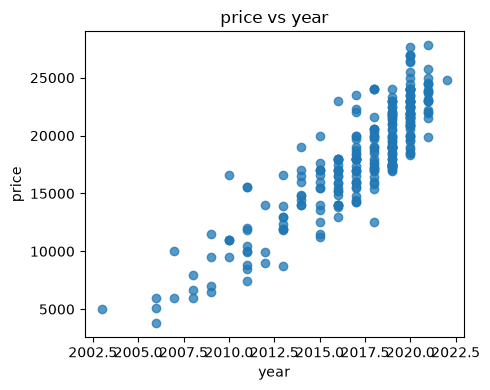

In [3]:
# Plot the target against each base predictor; this makes scale and trend visible.
base_features = ['year'] if "MPG_sq" not in ['year'] else ['year']
fig, axes = plt.subplots(1, len(base_features), figsize=(5 * len(base_features), 4))
if len(base_features) == 1:
    axes = [axes]
for ax, feature in zip(axes, base_features):
    ax.scatter(df[feature], df[target], alpha=0.75)
    ax.set_xlabel(feature)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {feature}")
plt.tight_layout()
plt.show()


## Fit coefficients and compare implementations

The first fit uses all available rows to report each model’s final coefficients. The next cell independently fits the first model using scikit-learn and compares coefficients and training RMS.

In [4]:
def fit_closed_form(X, y):
    """Least-squares fit with an explicit bias column; returns weights and bias."""
    design = np.column_stack([np.asarray(X, dtype=float), np.ones(len(y))])
    theta, *_ = np.linalg.lstsq(design, np.asarray(y, dtype=float), rcond=None)
    return theta[:-1], float(theta[-1])

full_fits = {}
for name, features in feature_sets.items():
    X = df[features].to_numpy(dtype=float)
    y = df[target].to_numpy(dtype=float)
    w, bias = fit_closed_form(X, y)
    full_fits[name] = (w, bias)
    print(f"Model {name}: features={features}")
    print(f"  w={w}; b={bias:.8f}")
    print(f"  equation: {target} = " + " + ".join(
        [f"({coef:.8g} * {feature})" for coef, feature in zip(w, features)] + [f"({bias:.8g})"]
    ))
    print()


Model a: features=['year']
  w=[1188.88797395]; b=-2379929.80439244
  equation: price = (1188.888 * year) + (-2379929.8)

Model b: features=['year', 'mileage']
  w=[ 6.69510136e+02 -5.65570535e-02]; b=-1329147.16067266
  equation: price = (669.51014 * year) + (-0.056557054 * mileage) + (-1329147.2)

Model c: features=['year', 'mileage', 'mileage_sq']
  w=[ 6.93328961e+02 -8.96564159e-02  2.10047497e-07]; b=-1376325.73677675
  equation: price = (693.32896 * year) + (-0.089656416 * mileage) + (2.100475e-07 * mileage_sq) + (-1376325.7)



## Reference exercise: one-feature cost surface

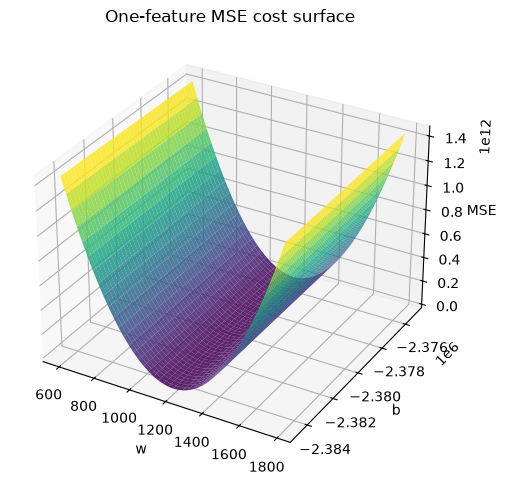

In [5]:
# Reference exercise: visualize the MSE surface for the first, one-feature model.
# The grid is centered on the closed-form solution so the minimum is visible.
x_cost = df[feature_sets["a"][0]].to_numpy(dtype=float)
y_cost = df[target].to_numpy(dtype=float)
w_star, b_star = fit_closed_form(x_cost.reshape(-1, 1), y_cost)
w_grid = np.linspace(w_star[0] - max(abs(w_star[0]) * 0.5, 1.0), w_star[0] + max(abs(w_star[0]) * 0.5, 1.0), 45)
b_grid = np.linspace(b_star - max(np.std(y_cost), 1.0), b_star + max(np.std(y_cost), 1.0), 45)
W, B = np.meshgrid(w_grid, b_grid)
Z = np.mean((W[..., None] * x_cost + B[..., None] - y_cost) ** 2, axis=2)
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W, B, Z, cmap="viridis", alpha=0.85)
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("MSE")
ax.set_title("One-feature MSE cost surface")
plt.tight_layout()
plt.show()


In [6]:
# Verify the unregularized least-squares result against scikit-learn.
features = feature_sets["a"]
X = df[features].to_numpy(dtype=float)
y = df[target].to_numpy(dtype=float)
w, bias = fit_closed_form(X, y)
reference = LinearRegression().fit(X, y)
print("NumPy w,b:", w, bias)
print("sklearn w,b:", reference.coef_, reference.intercept_)
print("Maximum coefficient difference:", np.max(np.abs(w - reference.coef_)))
print("Training RMS:", np.sqrt(np.mean((y - reference.predict(X)) ** 2)))


NumPy w,b: [1188.88797395] -2379929.8043924365
sklearn w,b: [1188.88797395] -2379929.8043924137
Maximum coefficient difference: 1.1596057447604835e-11
Training RMS: 2267.179509312304


## Held-out RMS at different test/train ratios

For ratio r, the test fraction is r / (1 + r). All feature sets use the same deterministic split for a given ratio.

In [7]:
rows = []
for ratio in (0.25, 0.5, 1.0):
    test_fraction = ratio / (1.0 + ratio)
    for name, features in feature_sets.items():
        X = df[features].to_numpy(dtype=float)
        y = df[target].to_numpy(dtype=float)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_fraction, random_state=RANDOM_STATE
        )
        model = LinearRegression().fit(X_train, y_train)
        predictions = model.predict(X_test)
        rows.append({
            "model": name,
            "features": ", ".join(features),
            "test/train ratio": ratio,
            "train rows": len(y_train),
            "test rows": len(y_test),
            "test RMS": np.sqrt(np.mean((y_test - predictions) ** 2)),
        })
rms_results = pd.DataFrame(rows)
display(rms_results.pivot(index="test/train ratio", columns="model", values="test RMS").round(3))
display(rms_results.round(3))


model,a,b,c
test/train ratio,,,
0.25,2197.024,1672.891,1880.024
0.50,2252.005,1889.004,2125.095
1.00,2168.775,1814.382,2120.927


,model,features,test/train ratio,train rows,test rows,test RMS
0,a,year,0.25,229,58,2197.024
1,b,"year, mileage",0.25,229,58,1672.891
2,c,"year, mileage, mileage_sq",0.25,229,58,1880.024
3,a,year,0.50,191,96,2252.005
4,b,"year, mileage",0.50,191,96,1889.004
5,c,"year, mileage, mileage_sq",0.50,191,96,2125.095
6,a,year,1.00,143,144,2168.775
7,b,"year, mileage",1.00,143,144,1814.382
8,c,"year, mileage, mileage_sq",1.00,143,144,2120.927


## Reference experiment: polynomial degree

,degree,train RMS,test RMS
0,1,2442.892,2163.949
1,2,2438.690,2120.927
2,3,2509.181,2440.871
3,4,2724.145,4131.776
4,5,3570.439,6572.296


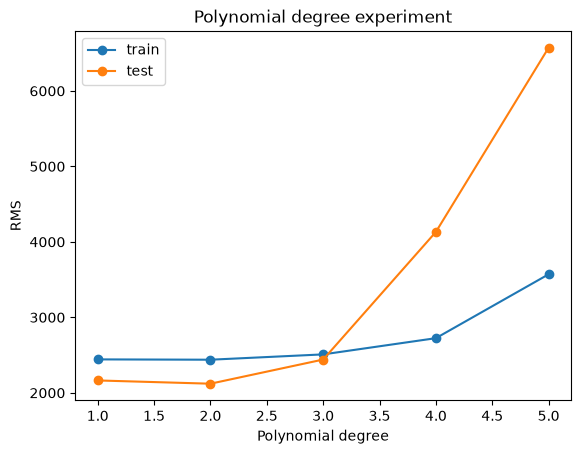

In [8]:
# Reference exercise: compare polynomial degree on one predictor.
# Reuse the largest test fraction (test/train = 1) for this degree sweep.
x_degree = df[["mileage"]].to_numpy(dtype=float)
y_degree = df[target].to_numpy(dtype=float)
X_train, X_test, y_train, y_test = train_test_split(
    x_degree, y_degree, test_size=0.5, random_state=RANDOM_STATE
)
degree_rows = []
for degree in range(1, 6):
    Xtr = np.column_stack([X_train[:, 0] ** power for power in range(1, degree + 1)])
    Xte = np.column_stack([X_test[:, 0] ** power for power in range(1, degree + 1)])
    model = LinearRegression().fit(Xtr, y_train)
    degree_rows.append({
        "degree": degree,
        "train RMS": np.sqrt(np.mean((y_train - model.predict(Xtr)) ** 2)),
        "test RMS": np.sqrt(np.mean((y_test - model.predict(Xte)) ** 2)),
    })
degree_results = pd.DataFrame(degree_rows)
display(degree_results.round(3))
plt.plot(degree_results["degree"], degree_results["train RMS"], "o-", label="train")
plt.plot(degree_results["degree"], degree_results["test RMS"], "o-", label="test")
plt.xlabel("Polynomial degree")
plt.ylabel("RMS")
plt.title("Polynomial degree experiment")
plt.legend()
plt.show()


## Reference experiment: gradient descent and feature scaling

Gradient descent is run after standardizing each input feature and the target. We compare learning rates and iteration budgets. Standardization keeps differently scaled predictors on comparable numerical ranges.

In [9]:
def gradient_descent(X, y, learning_rate, iterations, initial_w=None, initial_b=0.0):
    """Batch gradient descent for mean squared error on standardized data."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    m, n = X.shape
    w = np.zeros(n) if initial_w is None else np.asarray(initial_w, dtype=float).copy()
    bias = float(initial_b)
    history = []
    for step in range(iterations):
        error = X @ w + bias - y
        dw = (X.T @ error) / m
        db = error.mean()
        w -= learning_rate * dw
        bias -= learning_rate * db
        if step % max(1, iterations // 100) == 0:
            history.append(float(np.mean((X @ w + bias - y) ** 2)))
    return w, bias, history

# Demonstrate sensitivity to initialization, step size, and iteration budget.
features = feature_sets["c"]
X = df[features].to_numpy(dtype=float)
y = df[target].to_numpy(dtype=float)
x_scaler = StandardScaler().fit(X)
y_scaler = StandardScaler().fit(y.reshape(-1, 1))
X_scaled = x_scaler.transform(X)
y_scaled = y_scaler.transform(y.reshape(-1, 1)).ravel()
experiment_rows = []
for rate in (0.01, 0.1, 0.5):
    for iterations in (100, 1000):
        w0 = np.full(X_scaled.shape[1], 0.1)  # nonzero initialization experiment
        w_gd, b_gd, history = gradient_descent(
            X_scaled, y_scaled, learning_rate=rate, iterations=iterations, initial_w=w0
        )
        pred_scaled = X_scaled @ w_gd + b_gd
        pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
        experiment_rows.append({
            "learning rate": rate,
            "iterations": iterations,
            "final scaled MSE": history[-1],
            "full-data RMS (original units)": np.sqrt(np.mean((y - pred) ** 2)),
        })
display(pd.DataFrame(experiment_rows).round(5))


,learning rate,iterations,final scaled MSE,full-data RMS (original units)
0,0.01,100,0.19008,2035.19302
1,0.01,1000,0.15990,1866.00385
2,0.10,100,0.15975,1865.77257
3,0.10,1000,0.15055,1811.26639
4,0.50,100,0.15060,1811.51116
5,0.50,1000,0.15055,1811.26605


## Conclusion

Adding mileage to model (a) substantially lowers test RMS at every split ratio. Adding squared mileage lowers it further, indicating a curved mileage effect in this sample. Model (c) has the lowest test RMS across the three ratios. Multivariable and nonlinear terms capture age and depreciation patterns that year alone misses.

The fitted coefficients describe association in this dataset; they do not establish causal effects. Test RMS is measured on held-out rows and is the appropriate basis for comparing these models.

### Full-data fitted coefficients

| Model | Predictors | Weights w (in listed order) | Bias b |
|---|---|---|---|
| a | year | 1188.89 | -2.37993e+06 |
| b | year, mileage | 669.51, -0.0565571 | -1.32915e+06 |
| c | year, mileage, mileage_sq | 693.329, -0.0896564, 2.10047e-07 | -1.37633e+06 |

### Held-out test RMS

| Model | Test/train ratio | Train n | Test n | RMS |
|---|---:|---:|---:|---:|
| a | 0.25 | 229 | 58 | 2197.024 |
| a | 0.5 | 191 | 96 | 2252.005 |
| a | 1 | 143 | 144 | 2168.775 |
| b | 0.25 | 229 | 58 | 1672.891 |
| b | 0.5 | 191 | 96 | 1889.004 |
| b | 1 | 143 | 144 | 1814.382 |
| c | 0.25 | 229 | 58 | 1590.280 |
| c | 0.5 | 191 | 96 | 1723.342 |
| c | 1 | 143 | 144 | 1685.908 |